# Held-Suarez Forcing Test

This notebook uses Dinosaur to run Held-Suarez integration test[1]. In this test a heuristic forcing terms are added to the primitive equations to produce steady state solution. The goal is to reconstruct statistics of the equilibrium state.

The notebook is split into 3 parts:
1. We unroll a trajectory only using primitive equations to verify that no interesting steady state is reached on its own.
2. We inspect implementation of the Held-Suarez test forcing terms.
3. We run simulation with forcing terms added to the equation.

We recommend using GPU runtime for this notebook. By default the notebook uses T42 spherical harmonic grid and 24 model levels, but higher resolution settings (e.g. T85 and 32 model levels can be used for higher-resolution results)

[1]  Held, I. M., and M. J. Suarez, 1994: "A proposal for the intercomparison of
  the dynamical cores of atmospheric general circulation models."
  Bulletin of the American Meteorological Society, 75, 1825–1830.

In [1]:
import functools
import jax
import jax.numpy as jnp
#import dinosaur
import sys
import os
# Get the absolute path of the parent directory
parent_dir = os.path.abspath(os.path.join('~', 'ai', 'hybrid_comp', 'dinosaur'))
sys.path.insert(0, parent_dir)
import dinosaur
from dinosaur.primitive_equations import State
import numpy as np
import matplotlib.pyplot as plt
import xarray
import functools

units = dinosaur.scales.units

def dimensionalize(x: xarray.DataArray, unit: units.Unit) -> xarray.DataArray:
  """Dimensionalizes `xarray.DataArray`s."""
  dimensionalize = functools.partial(physics_specs.dimensionalize, unit=unit)
  return xarray.apply_ufunc(dimensionalize, x)

## Settings

In [2]:
# Resolution
n_gpus = len(jax.devices())
print(n_gpus)
if n_gpus > 1:
    # need spmd_mesh sent to horiz_coord too?
    spmd_mesh = jax.make_mesh((1, 2, 1), ('z', 'x', 'y'))
    P = jax.sharding.PartitionSpec('z', 'x', 'y')  # this controls sharding over which axes; for just two ig split of 'x' (assuming lon?)
    # not really apparent if sharding different axes is any more efficient
    sharding = jax.sharding.NamedSharding(spmd_mesh, P)
else:
    spmd_mesh = None

units = dinosaur.scales.units
layers = 200

# sharded coordinates/data
### FastSphericalHarmonics ONLY WORKS FOR T42 and T106 (with triangular truncation?)
### OK 'rhombus' truncation solves all probs for T* models all work .?? why would that be?
horiz_coord = dinosaur.spherical_harmonic.Grid.T42(
    spherical_harmonics_impl=dinosaur.spherical_harmonic.FastSphericalHarmonics,
)

coords = dinosaur.coordinate_systems.CoordinateSystem(
    horizontal=horiz_coord,
    vertical=dinosaur.sigma_coordinates.SigmaCoordinates.equidistant(layers),
    spmd_mesh=spmd_mesh  # AFAIK this will overwrite spmd_mesh in the horizontal Grid() instance so can just supply here
)  # this should also automatically shard the data so no need for device_put(data, sharding) (?)

physics_specs = dinosaur.primitive_equations.PrimitiveEquationsSpecs.from_si()

p0 = 100e3 * units.pascal
p1 = 5e3 * units.pascal
rng_key = jax.random.PRNGKey(0)

1


## Isothermal Rest Atmosphere

In [3]:
# Smooth Planet (no orography)
initial_state_fn, aux_features = dinosaur.primitive_equations_states.isothermal_rest_atmosphere(
    coords=coords,
    physics_specs=physics_specs,
    p0=p0,
    p1=p1)
initial_state, nodal_surf_pressure = initial_state_fn(rng_key)
ref_temps = aux_features[dinosaur.xarray_utils.REF_TEMP_KEY]
orography = dinosaur.primitive_equations.truncated_modal_orography(
    aux_features[dinosaur.xarray_utils.OROGRAPHY], coords)

# for shard in initial_state.log_surface_pressure.addressable_shards:
#     print(f"device {shard.device} has local data {shard.data}")

In [27]:
#@test {"skip": true}

initial_state_dict, _ = dinosaur.pytree_utils.as_dict(initial_state)
u, v = dinosaur.spherical_harmonic.vor_div_to_uv_nodal(
    coords.horizontal, initial_state.vorticity, initial_state.divergence
)
initial_state_dict.update({'u': u, 'v': v, 'orography': orography})
nodal_steady_state_fields = dinosaur.coordinate_systems.maybe_to_nodal(
    initial_state_dict, coords=coords
)
# need this serialize...=False if running distributed, spmd_mesh is not picklable
initial_state_ds = dinosaur.xarray_utils.data_to_xarray(
    nodal_steady_state_fields, coords=coords, times=None, serialize_coords_to_attrs=False
)

temperature = dinosaur.xarray_utils.temperature_variation_to_absolute(
    initial_state_ds.temperature_variation.data, ref_temps
)
initial_state_ds = initial_state_ds.assign(
    temperature=(initial_state_ds.temperature_variation.dims, temperature)
)
surface_pressure = np.exp(initial_state_ds.log_surface_pressure.data[0, ...])  # this is equiv to log_surface_pressure.data[0]
# assume *[0, ...] just preserves any later dims
initial_state_ds = initial_state_ds.assign(
    surface_pressure=(initial_state_ds.log_surface_pressure.dims[1:], surface_pressure)
)

## Plot initial state

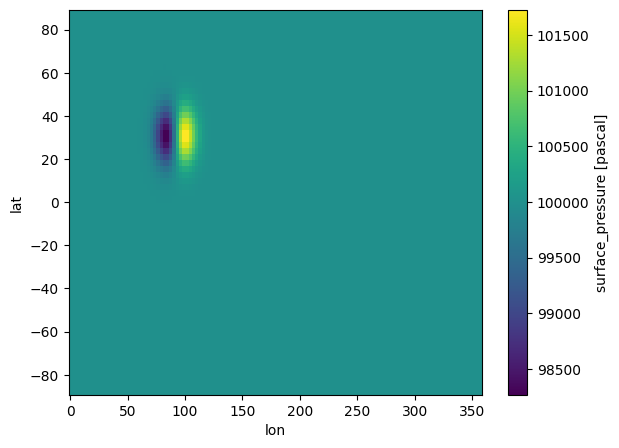

In [5]:
#@test {"skip": true}
#@title Surface Pressure {form-width: "40%"}
pressure_array = initial_state_ds['surface_pressure']
pressure_array_si = dimensionalize(pressure_array, units.pascal)
pressure_array_si.plot.imshow(x='lon', y='lat', size=5)

## Integration of the state in time

In [5]:
# Integration settings
dt_si = 1 * units.minute
save_every = 10 * units.minute
# save_every = 20 * units.minute
total_time = 24 * units.hour
# total_time = 48 * units.hour

inner_steps = int(save_every / dt_si)
outer_steps = int(total_time / save_every)
dt = physics_specs.nondimensionalize(dt_si)

# Governing equations
primitive = dinosaur.primitive_equations.PrimitiveEquations(
    ref_temps,
    orography,
    coords,
    physics_specs)

# Implicit/Explicit integrator
integrator = dinosaur.time_integration.imex_rk_sil3
step_fn = integrator(primitive, dt)
filters = [
    dinosaur.time_integration.exponential_step_filter(coords.horizontal, dt)]
step_fn = dinosaur.time_integration.step_with_filters(step_fn, filters)
integrate_fn = jax.jit(dinosaur.time_integration.trajectory_from_step(
    step_fn,
    outer_steps=outer_steps,
    inner_steps=inner_steps,
    start_with_input=True))

# Define trajectory times, expects start_with_input=True
times = save_every * np.arange(0, outer_steps)

In [6]:
# Unrolling trajectory
%time final, traj = jax.block_until_ready(integrate_fn(initial_state))

CPU times: user 5.69 s, sys: 680 ms, total: 6.37 s
Wall time: 6.07 s


In [4]:
# Formatting trajectory to xarray.Dataset
## this is painfully slow when running on multiple devices... is there a way around that tho?
## also uses a shitload of memory; either bc ds is replicated on both devs or just bc the field is big idk
## would using a dask cluster help? or some other parallelization? would need a sig rewrite to handle 4D objects with mesh
## NOTE 
def trajectory_to_xarray(coords, trajectory_full, times):
    out_ds = []
    for i in range(trajectory_full.divergence.shape[0]):
        trajectory = State(
            divergence=trajectory_full.divergence[i, ...],
            vorticity=trajectory_full.vorticity[i, ...],
            temperature_variation=trajectory_full.temperature_variation[i, ...],
            log_surface_pressure=trajectory_full.log_surface_pressure[i, ...],
            tracers={'qv': trajectory_full.tracers['qv'][i, ...]},
            #precip=trajectory_full.precip[i, ...]
        )
        trajectory_dict, _ = dinosaur.pytree_utils.as_dict(trajectory)  # tracers is in here
        u, v = dinosaur.spherical_harmonic.vor_div_to_uv_nodal(
            coords.horizontal, trajectory.vorticity, trajectory.divergence
        )
        trajectory_dict.update({'u': u, 'v': v})
        nodal_trajectory_fields = dinosaur.coordinate_systems.maybe_to_nodal(
            trajectory_dict, coords=coords
        )
        trajectory_ds = dinosaur.xarray_utils.data_to_xarray(
            nodal_trajectory_fields, coords=coords, times=None, serialize_coords_to_attrs=False
        )
        ## below diff only by times=times...
        # trajectory_ds = dinosaur.xarray_utils.data_to_xarray(
        #     nodal_trajectory_fields, coords=coords, times=times, serialize_coords_to_attrs=False)
        
        # trajectory_ds['surface_pressure'] = np.exp(trajectory_ds.log_surface_pressure[:, 0, :,:])
        trajectory_ds['surface_pressure'] = np.exp(trajectory_ds.log_surface_pressure[0, :,:])
        temperature = dinosaur.xarray_utils.temperature_variation_to_absolute(
            trajectory_ds.temperature_variation.data, ref_temps
        )
        trajectory_ds = trajectory_ds.assign(
            temperature=(trajectory_ds.temperature_variation.dims, temperature)
        )
        total_layer_ke = coords.horizontal.integrate(u**2 + v**2)
        total_ke_cumulative = dinosaur.sigma_coordinates.cumulative_sigma_integral(
            total_layer_ke, coords.vertical, axis=-1)
        total_ke = total_ke_cumulative[..., -1]
        trajectory_ds = trajectory_ds.assign(total_kinetic_energy=(total_ke))
        out_ds.append(trajectory_ds)

    final_ds = xarray.concat(out_ds, times)
    final_ds = final_ds.rename({'concat_dim': 'time'})
    return final_ds

In [ ]:
%time ds = trajectory_to_xarray(coords, jax.device_get(traj), times)

In [8]:
## should this look like this? just 0 everywhere during test rollout.?
# think so bc i only include qv tendency in hs_forcing and initial state has no qv anywhere
# qv = ds['qv']
# qv_si = dimensionalize(qv, units.g / units.kg)
# qv_si.isel(level=19).isel(time=slice(0, 18, 4)).plot(x='lon', y='lat', col='time', col_wrap=6)

## Plot trajectory

In [9]:
# Surface Pressure Variation
# data_array = ds['surface_pressure'] - ds['surface_pressure'].isel(time=0)
# data_array_si = dimensionalize(data_array, units.pascal)
# data_array_si.isel(time=slice(0, 18, 4)).plot(x='lon', y='lat', col='time', col_wrap=6)

In [10]:
# Vorticity (near earth surface)
# data_array = ds['vorticity']
# data_array.isel(level=10).isel(time=slice(0, 18, 4)).plot(x='lon', y='lat', col='time', col_wrap=6)

In [11]:
# Total Kinetic Energy
# data_array = ds['total_kinetic_energy']
# data_array.plot(x='time')
# ax = plt.gca()
# ax.legend().remove();

# Held-Suarez Forcing

In [5]:
hs = dinosaur.held_suarez.HeldSuarezForcingTracers(
    coords=coords,
    physics_specs=physics_specs,
    reference_temperature=ref_temps,
    p0=p0)

## Plot Held-Suarez coefficients and radiative equilibrium

See Held-Suarez 1994 publication figures for comparison.

In [6]:
def ds_held_suarez_forcing(coords):
  grid = coords.horizontal
  sigma = coords.vertical.centers
  lon, _ = grid.nodal_mesh
  surface_pressure = physics_specs.nondimensionalize(p0) * np.ones_like(lon)
  dims = ('sigma', 'lon', 'lat')
  return xarray.Dataset(
      data_vars={
          'surface_pressure': (('lon', 'lat'), surface_pressure),
          'eq_temp': (dims, hs.equilibrium_temperature(surface_pressure)),
          'kt': (dims, hs.kt()),
          'kv': ('sigma', hs.kv()[:, 0, 0]),
      },
      coords={'lon': grid.nodal_axes[0] * 180 / np.pi,
              'lat': np.arcsin(grid.nodal_axes[1]) * 180 / np.pi,
              'sigma': sigma},
  )

ds = ds_held_suarez_forcing(coords)

def linspace_step(start, stop, step):
  num = round((stop - start) / step) + 1
  return np.linspace(start, stop, num)

In [14]:
# Friction coefficient {form-width: "40%"}
# kv = ds['kv']
# kv_si = dimensionalize(kv, 1 / units.day)
# kv_si.plot(size=5)

In [15]:
# Thermal relaxation coefficient {form-width: "40%"}
# kt_array = ds['kt']
# levels = linspace_step(0, 0.3, 0.05)
# kt_array_si = dimensionalize(kt_array, 1 / units.day)
# p = kt_array_si.isel(lon=0).plot.contour(x='lat', y='sigma', levels=levels,
#                                          size=5, aspect=1.5)
# ax = plt.gca()
# ax.set_ylim((1, 0))
#plt.colorbar(p);

In [17]:
# Radiative equilibrium temperature {form-width: "40%"}
# teq_array = ds['eq_temp']
# teq_array_si = dimensionalize(teq_array, units.degK)
# levels = linspace_step(205, 310, 5)
# p = teq_array_si.isel(lon=0).plot.contour(x='lat', y='sigma', levels=levels,
#                                           size=5, aspect=1.5)
# ax = plt.gca()
# ax.set_ylim((1, 0));
#plt.colorbar(p);

In [18]:
# Radiative equilibrium potential temperature {form-width: "40%"}
# temperature = dimensionalize(ds['eq_temp'], units.degK)
# surface_pressure = dimensionalize(ds['surface_pressure'], units.pascal)
# pressure = ds.sigma * surface_pressure
# kappa = dinosaur.scales.KAPPA  # kappa = R / cp, R = gas constant, cp = specific heat capacity
# potential_temperature = temperature * (pressure / p0)**-kappa

# levels = linspace_step(260, 325, 5)
# levels = np.concatenate([levels, np.array([350, 400, 450, 500, 550, 600])], axis=0)
# p = potential_temperature.isel(lon=0).plot.contour(x='lat', y='sigma', levels=levels,
#                                                    size=5, aspect=1.5)
# ax = plt.gca()
# ax.set_ylim((1, 0));
# plt.colorbar(p)

# print(potential_temperature.min())
# print(potential_temperature.max())
# Stable for d(potential temperature)/dz > 0

# Integrating with Held-Suarez Forcing

In [7]:
# Integration settings
dt_si = 1 * units.minute
save_every = 1 * units.day
# save_every = 6 * units.hour
total_time = 100 * units.day
# total_time = 100 * units.day

inner_steps = int(save_every / dt_si)
outer_steps = int(total_time / save_every)
dt = physics_specs.nondimensionalize(dt_si)

# Governing equations
primitive = dinosaur.primitive_equations.PrimitiveEquations(
    ref_temps,
    orography,
    coords,
    physics_specs)

# This is what needs to take care of tracer advection.. somehow
hs_forcing = dinosaur.held_suarez.HeldSuarezForcingTracers(
    coords=coords,
    physics_specs=physics_specs,
    reference_temperature=ref_temps,
    p0=p0)

primitive_with_hs = dinosaur.time_integration.compose_equations([primitive, hs_forcing])

step_fn = dinosaur.time_integration.imex_rk_sil3(primitive_with_hs, dt)
filters = [
    dinosaur.time_integration.exponential_step_filter(
        coords.horizontal, dt, tau=0.0087504, order=1.5, cutoff=0.8),
]

step_fn = dinosaur.time_integration.step_with_filters(step_fn, filters)
integrate_fn = jax.jit(dinosaur.time_integration.trajectory_from_step(
    step_fn,
    outer_steps=outer_steps,
    inner_steps=inner_steps))

# Define trajectory times, expects start_with_input=False
times = save_every * np.arange(1, outer_steps+1)

In [8]:
# print(initial_state)
%time final, traj = jax.block_until_ready(integrate_fn(initial_state))

CPU times: user 5min 22s, sys: 6min 13s, total: 11min 35s
Wall time: 11min 25s


In [9]:
%time ds = trajectory_to_xarray(coords, jax.device_get(traj), times)

CPU times: user 3.68 s, sys: 340 ms, total: 4.02 s
Wall time: 3.78 s


In [14]:
# Total Kinetic Energy
# data_array = ds['total_kinetic_energy']
# # data_array = dimensionalize(data_array, units.degK)
# data_array.plot(x='time')
# ax = plt.gca()
# ax.legend().remove();

In [10]:
def vapor_pressure(q, p):
    return q * p / (0.622 + 0.378 * q)

def saturation_vapor_pressure(temperature):
    T0 = 273.15  # K
    T = temperature - T0
    return 610.94 * np.exp(17.625 * T / (T + 243.04)) * units.pascal  # saturation vapor pressure (Pa)

def get_precip(hs_forcing: dinosaur.held_suarez.HeldSuarezForcingTracers) -> xarray.DataArray:
    print(type(hs_forcing.surface_precip[0]))
    precip = np.stack(hs_forcing.surface_precip, axis=0)
    print(precip.shape)
    # precip *= ()
    # turn into xr ds, has dims of (time, lat, lon)
    precip_ds = xarray.DataArray(data=precip, dims=['time', 'lon', 'lat'])
    return precip_ds

-56629.875 5995.136


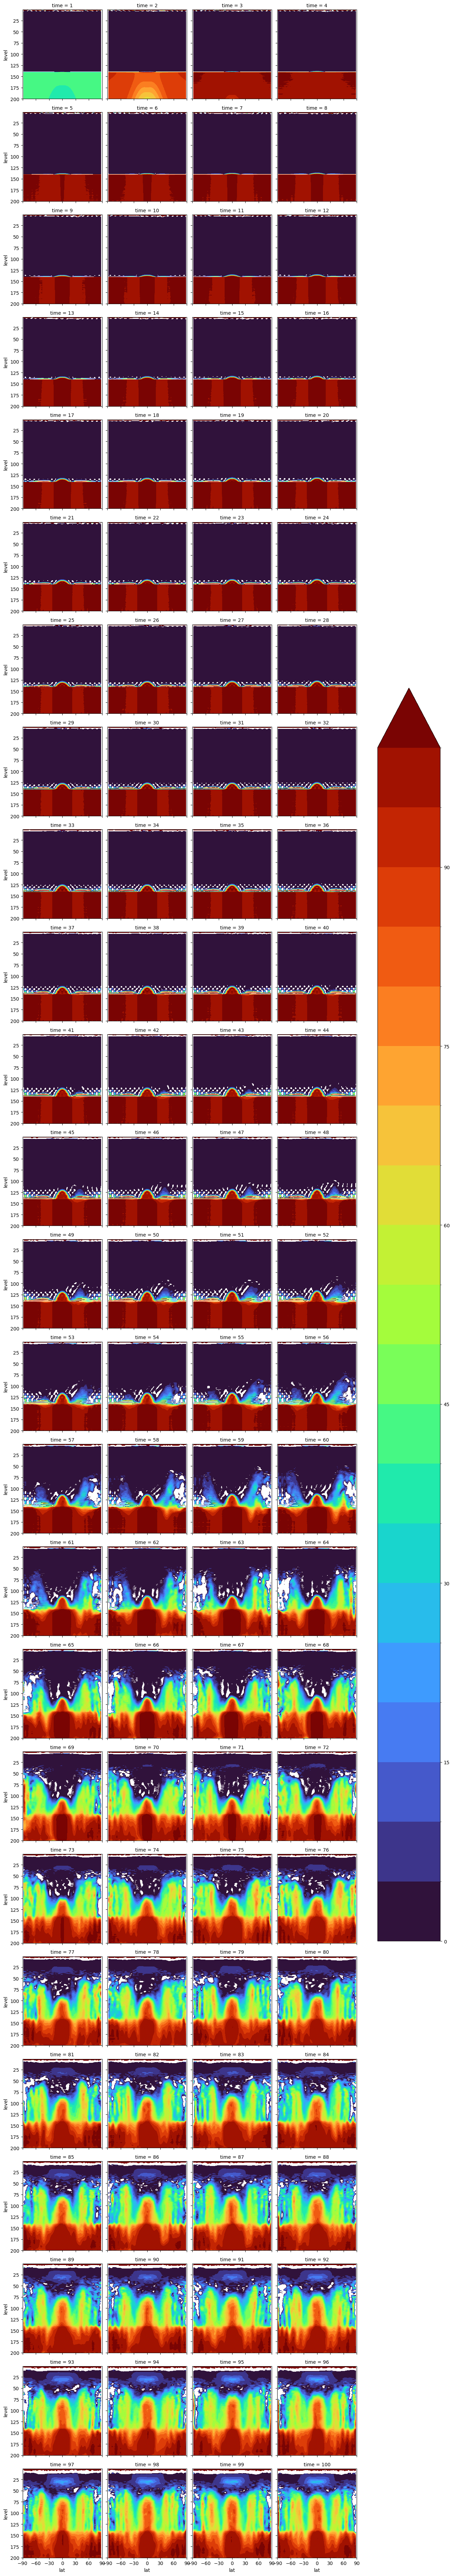

In [11]:
mask = ds['time'] <= 100  # days
qv = ds['qv']  # this in g/kg? still way too high 854 g/kg??
print(qv.min().data, qv.max().data)  # plus getting extreme negative values ~ -50k

# pressure
surface_pressure = dimensionalize(ds['surface_pressure'], units.pascal)
pressure = ds.level * surface_pressure

# for potential temperature
temperature = ds['temperature']
kappa = dinosaur.scales.KAPPA  # kappa = R / cp, R = gas constant, cp = specific heat capacity
potential_temperature = temperature * (pressure / p0)**-kappa

# relative humidity
esat = saturation_vapor_pressure(temperature)
evap = vapor_pressure(qv, pressure)
RH = evap / esat * 100

# set negative values to nan for vis
RH = RH.as_numpy()
RH = RH.where(RH > 0, RH)

levels = linspace_step(0, 100, 5)
RH = RH.assign_coords(level=np.arange(1, layers + 1, 1))
RH.isel(time=mask).mean('lon').plot.contourf(
    x='lat', y='level', col='time', col_wrap=4, levels=levels, cmap='turbo', add_colorbar=True, extend='max'
)

# levels = linspace_step(260, 325, 5)
# levels = np.concatenate([levels, np.array([350, 400, 450, 500, 550, 600])], axis=0)

# p = potential_temperature.isel(time=mask).mean(['lon', 'time']).plot.contour(ax=pltobj,
#     x='lat', y='level', levels=levels)

ax = plt.gca()
ax.set(xticks=np.arange(-90, 91, 30))
ax.set_ylim((layers, 1));
# plt.savefig('./tracer_rh.png', dpi=300)

## why the hell wont anything leave the fake PBL.? now relaxing lower 30% to saturation
## are the time steps now unreasonable in the H-S forcing..? like kf/ka/k? are scaled per day
## idk if using such a small time step or high vertical resolution is screwing things up? idk why it would
### but Yi's paper says:
# "The model analyzed here has a spectral dynamical core with a horizontal resolution of T42, and 20 equally spaced vertical sigma layers. //
# There is no claim that this simulation is converged as horizontal and especially vertical resolution is increased"

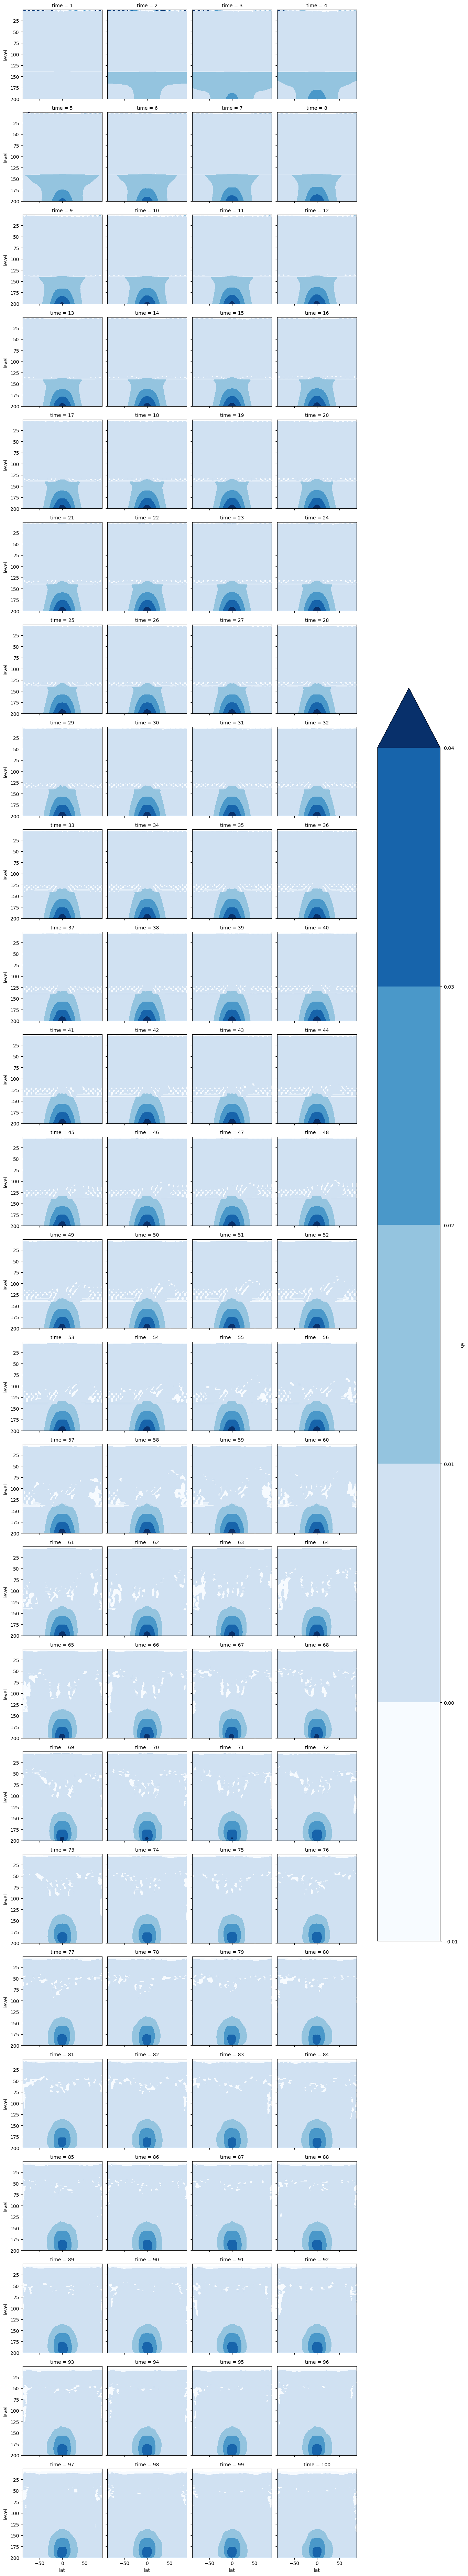

In [12]:
mask = ds['time'] <= 100  # days
qv = ds['qv']
levels = np.linspace(-.01, .04, 6)
qv = qv.assign_coords(level=np.arange(1, layers + 1, 1))
qv.isel(time=mask).mean('lon').plot.contourf(
    x='lat', y='level', col='time', col_wrap=4, levels=levels, cmap='Blues', add_colorbar=True, extend='max'
)
ax = plt.gca()
ax.set_ylim((layers, 1));

In [ ]:
###### Temperature
mask = ds['time'] <= 150  # days
data_array = ds['temperature']
data_array.isel(level=-1, time=mask).plot(
    x='lon', y='lat', col='time', col_wrap=4)

###### Vorticity
mask = ds['time'] <= 150  # days
data_array = ds['vorticity']
data_array.isel(level=-1, time=mask).plot(
    x='lon', y='lat', col='time', col_wrap=4)

In [ ]:
###### Temperature
mask = ds['time'] <= 150  # days
data_array = ds['temperature']
data_array = dimensionalize(data_array, units.degK)
levels = linspace_step(190, 305, 5)
data_array.isel(time=mask).mean('lon').plot.contour(
    x='lat', y='level', col='time', col_wrap=4, levels=levels)
ax = plt.gca()
ax.set_ylim((1, 0));

## Plots for `time > start_time`, averaged over time and longitude

In [ ]:
###### start_time = 200 # days

In [ ]:
###### Mean QV?
mask = ds['time'] > start_time
qv = ds['qv']
temperature = ds['temperature']
p_surf = ds['surface_pressure']
p_surf = dimensionalize(p_surf, units.pascal)
p = pressure(p_surf, coords)  # ig this wont be a data array
esat = saturation_vapor_pressure(temperature)
evap = vapor_pressure(qv, p)
RH = evap / esat * 100

levels = linspace_step(0, 100, 5)
RH.isel(time=mask).mean('lon').plot.contourf(
    x='lat', y='level', col='time', col_wrap=4, levels=levels, cmap='Blues', add_colorbar=True, extend='max'
)
ax = plt.gca()
ax.set_ylim((1, 0));

In [ ]:
###### Mean Temperature
mask = ds['time'] > start_time
data_array = ds['temperature']
data_array = dimensionalize(data_array, units.degK)
levels = linspace_step(190, 305, 5)
data_array.isel(time=mask).mean(['lon', 'time']).plot.contour(
    x='lat', y='level', levels=levels, size=5, aspect=1.5)
ax = plt.gca()
ax.set_ylim((1, 0));

In [ ]:
###### Mean Potential Temperature
mask = ds['time'] > start_time  # start with day=84 (12 weeks)
temperature = dimensionalize(ds['temperature'], units.degK)
surface_pressure = dimensionalize(ds['surface_pressure'], units.pascal)
pressure = ds.level * surface_pressure
kappa = dinosaur.scales.KAPPA  # kappa = R / cp, R = gas constant, cp = specific heat capacity
potential_temperature = temperature * (pressure / p0)**-kappa

levels = linspace_step(260, 325, 5)
levels = np.concatenate([levels, np.array([350, 400, 450, 500, 550, 600])], axis=0)
p = potential_temperature.isel(time=mask).mean(['lon', 'time']).plot.contour(
    x='lat', y='level', levels=levels, size=5, aspect=1.5)
ax = plt.gca()
ax.set_ylim((1, 0));

In [ ]:
###### Zonal Mean Wind
mask = ds['time'] > start_time
data_array = ds['u']
data_array = dimensionalize(data_array, units.meter / units.s)
levels = linspace_step(-20, 28, 4)
data_array.isel(time=mask).mean(['lon', 'time']).plot.contour(
    x='lat', y='level', levels=levels, size=5, aspect=1.5)
ax = plt.gca()
ax.set_ylim((1, 0));

In [ ]:
###### Eddy kinetic energy {form-width: "40%"}
mask = ds['time'] > start_time
data_array = ds['u']

data_array2 = ds['v']
data_array = dimensionalize(data_array, units.meter / units.s)
data_array2 = dimensionalize(data_array2, units.meter / units.s)

mean_u = data_array.isel(time=mask).mean(['time'])
zonal_u = data_array.isel(time=mask)

mean_v = data_array2.isel(time=mask).mean(['time'])
zonal_v = data_array2.isel(time=mask)


eke = (zonal_u - mean_u)**2 + (zonal_v - mean_v)**2
# levels = linspace_step(5, 45, 5)
#levels = 30
p = eke.mean(['time', 'lon']).plot(
    x='lat', y='level', size=5, aspect=1.5)
ax = plt.gca()
ax.set_ylim((1, 0));
# plt.colorbar(p)

###### Visualizing steady state dynamics after 1200 Days

###### assert False

In [ ]:
###### Integration settings
dt_si = 10 * units.minute
save_every = 6 * units.hours
total_time = 1 * units.week

inner_steps = int(save_every / dt_si)
outer_steps = int(total_time / save_every)
dt = physics_specs.nondimensionalize(dt_si)

# Leapfrog integrator
step_fn = dinosaur.time_integration.imex_rk_sil3(primitive_with_hs, dt)
filters = [
    dinosaur.time_integration.exponential_step_filter(
        coords.horizontal, dt, tau=0.0087504, order=1.5, cutoff=0.8),
]
step_fn = dinosaur.time_integration.step_with_filters(step_fn, filters)
integrate_fn = jax.jit(dinosaur.time_integration.trajectory_from_step(
    step_fn,
    outer_steps=outer_steps,
    inner_steps=inner_steps,
))

times = save_every * np.arange(1, outer_steps+1)

###### %time final_2, trajectory_2 = jax.block_until_ready(integrate_fn(final))

###### ds = trajectory_to_xarray(coords, trajectory_2, times)

###### Temperature
data_array = ds['temperature']
data_array.thin(time=4).isel(level=-10).plot(x='lon', y='lat', col='time')

###### Vorticity
data_array = ds['vorticity']
data_array.thin(time=4).isel(level=-5).plot(x='lon', y='lat', col='time')

###### 